# Run comparison

Compares runs from the scores `jev-model eval` saved in each run directory (`RUN/<stage>-<partition>.json`, or
`RUN/last-<partition>.json` for the last stage). Nothing is evaluated here, so run `eval` first.

Every finished stage of every run is one entry. Scores cover only the datasets every entry has, and `macro` is
taken again over those, so entries trained on different dataset sets stay comparable.

In [1]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from jev_model.constants import RUNS_DIR

# which runs to compare: globs under RUNS_DIR, e.g. ["pointer/*", "zero_shot/20261004-142713"]
RUNS = ["*/*"]
# only these stages; None for every finished one
STAGES: list[str] | None = None
PARTITION = "test"
# the metric of the heatmap, head to head and topic plots
METRIC = "accuracy"
# head to head: indexes into the leaderboard (0 is the best entry), or entry labels
RUN_A, RUN_B = 1, 0

METRICS = ["accuracy", "nll", "ece"]
HIGHER_IS_BETTER = {"accuracy": True, "nll": False, "ece": False}

/home/sbazhmin/rujev/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# categorical slots in fixed order (color follows the entry, never its rank); a sequential blue for magnitude and
# a blue/orange pair for polarity
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
SEQUENTIAL = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#a9c8ef", "#2a78d6", "#0d3b73"])
GAIN, LOSS = "#2a78d6", "#eb6834"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 9,
        "axes.edgecolor": GRID,
        "axes.labelcolor": MUTED,
        "axes.titlecolor": INK,
        "axes.titlesize": 10,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "legend.frameon": False,
    }
)

## Load the saved scores

In [3]:
def run_name(run, info: dict) -> str:
    """the model, plus the served LM for `zero_shot`, whose runs differ only by it"""
    name = info["model"]
    config = run / "config.json"
    if name == "zero_shot" and config.exists():
        name += " " + json.loads(config.read_text())["model"].split("/")[-1]
    return name


def entries() -> list[tuple[str, dict]]:
    """(label, {dataset: metrics}) for every finished stage that `eval` scored."""
    found = []
    run_dirs = sorted({p.parent for pattern in RUNS for p in RUNS_DIR.glob(f"{pattern}/run.json")})
    for run in run_dirs:
        info = json.loads((run / "run.json").read_text())
        stages = info.get("stages", [])
        for stage in stages:
            if STAGES and stage not in STAGES:
                continue
            path = run / f"{stage}-{PARTITION}.json"
            # `eval` without --stage scores the last stage
            if not path.exists() and stage == stages[-1]:
                path = run / f"last-{PARTITION}.json"
            if not path.exists():
                print(f"{run}: {stage} has no {PARTITION} scores, run `jev-model eval {run} --stage {stage}`")
                continue
            scores = json.loads(path.read_text())
            scores.pop("macro", None)
            found.append((f"{run_name(run, info)} {run.name} / {stage}", scores))
    return found


def dataset_info() -> pd.DataFrame:
    """topic (the converter's subpackage) and type of each registered dataset"""
    try:
        from jev_datasets import datasets
    except ImportError:
        return pd.DataFrame(columns=["topic", "type"])
    rows = {name: (type(ds).__module__.split(".")[1], ds.type.value) for name, ds in datasets.items()}
    return pd.DataFrame.from_dict(rows, orient="index", columns=["topic", "type"])


loaded = entries()
assert loaded, f"no saved {PARTITION} scores under {RUNS_DIR} for {RUNS}"
long = pd.DataFrame([{"entry": label, "dataset": name, **m} for label, scores in loaded for name, m in scores.items()])
order = [label for label, _ in loaded]
long["entry"] = pd.Categorical(long["entry"], order)
# generation-based runs give no probabilities, so their nll and ece are NaN
long[METRICS] = long[METRICS].astype(float)

counts = long.groupby("dataset", observed=True)["entry"].nunique()
common = sorted(counts[counts == len(order)].index)
left_out = sorted(counts[counts < len(order)].index)
df = long[long["dataset"].isin(common)].join(dataset_info(), on="dataset")
df[["topic", "type"]] = df[["topic", "type"]].fillna("?")
color = dict(zip(order, PALETTE * (len(order) // len(PALETTE) + 1)))
if len(order) > len(PALETTE):
    print(f"{len(order)} entries share {len(PALETTE)} colors; narrow RUNS or STAGES")

print(f"{len(order)} entries, {len(common)} common datasets")
if left_out:
    print(f"not in every entry, left out: {', '.join(left_out)}")

4 entries, 54 common datasets


## Leaderboard

`macro` is the unweighted mean over the common datasets; `mean rank` ranks the entries on each dataset (1 is
best) by `METRIC`; `wins` counts the datasets where an entry is best, ties included.

In [4]:
def wide(metric: str) -> pd.DataFrame:
    """datasets x entries"""
    return df.pivot(index="dataset", columns="entry", values=metric)[order]


def best_first(values: pd.Series, metric: str) -> pd.Series:
    return values.sort_values(ascending=not HIGHER_IS_BETTER[metric], na_position="last")


macro = pd.DataFrame({m: wide(m).mean(skipna=False) for m in METRICS})
table = wide(METRIC)
ranks = table.rank(axis=1, ascending=not HIGHER_IS_BETTER[METRIC])
best = table.max(axis=1) if HIGHER_IS_BETTER[METRIC] else table.min(axis=1)
leaderboard = macro.assign(
    **{"mean rank": ranks.mean(), "wins": table.eq(best, axis=0).sum(), "median": table.median()}
).loc[best_first(macro[METRIC], METRIC).index]
leaderboard.style.format(precision=3, na_rep="–").background_gradient(
    cmap=SEQUENTIAL, subset=[m for m in METRICS if HIGHER_IS_BETTER[m]], axis=0
)

,accuracy,nll,ece,mean rank,wins,median
entry,,,,,,
pointer 20261003-174824 / ce,0.865,0.381,0.039,1.296,44,0.931
typesafe 20261004-222225 / api,0.788,1.093,0.086,2.093,10,0.833
zero_shot gemma-4-26B-A4B-it 20261004-142713 / generate,0.751,–,–,2.741,0,0.813
zero_shot Qwen3.5-2B 20261004-130157 / generate,0.531,–,–,3.870,0,0.521


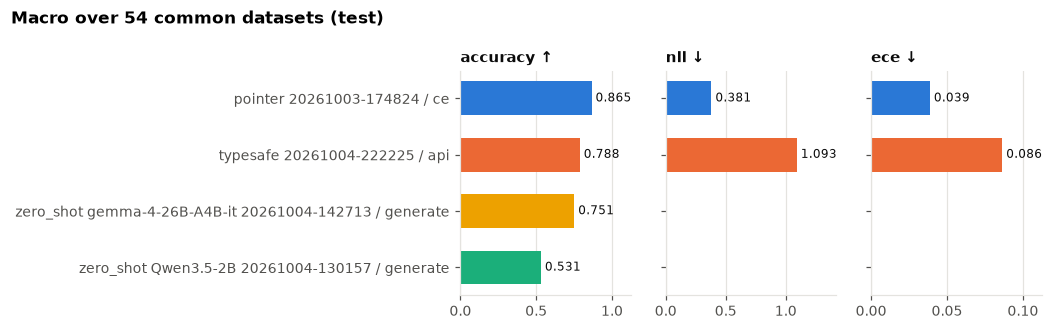

In [5]:
def bar_label(ax, bars, values):
    for bar, v in zip(bars, values):
        if not math.isnan(v):
            ax.text(
                bar.get_width(), bar.get_y() + bar.get_height() / 2, f" {v:.3f}", va="center", color=INK, fontsize=8
            )


shown = [m for m in METRICS if macro[m].notna().any()]
fig, axes = plt.subplots(1, len(shown), figsize=(3.2 * len(shown), 0.45 * len(order) + 1.2), sharey=True)
ranked = list(leaderboard.index)[::-1]
for ax, m in zip(np.atleast_1d(axes), shown):
    values = macro.loc[ranked, m]
    bars = ax.barh(ranked, values.fillna(0), color=[color[e] for e in ranked], height=0.6)
    bar_label(ax, bars, values)
    ax.set_title(f"{m} {'↑' if HIGHER_IS_BETTER[m] else '↓'}")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, (values.max() or 1) * 1.3)
fig.suptitle(f"Macro over {len(common)} common datasets ({PARTITION})", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()

## Every dataset

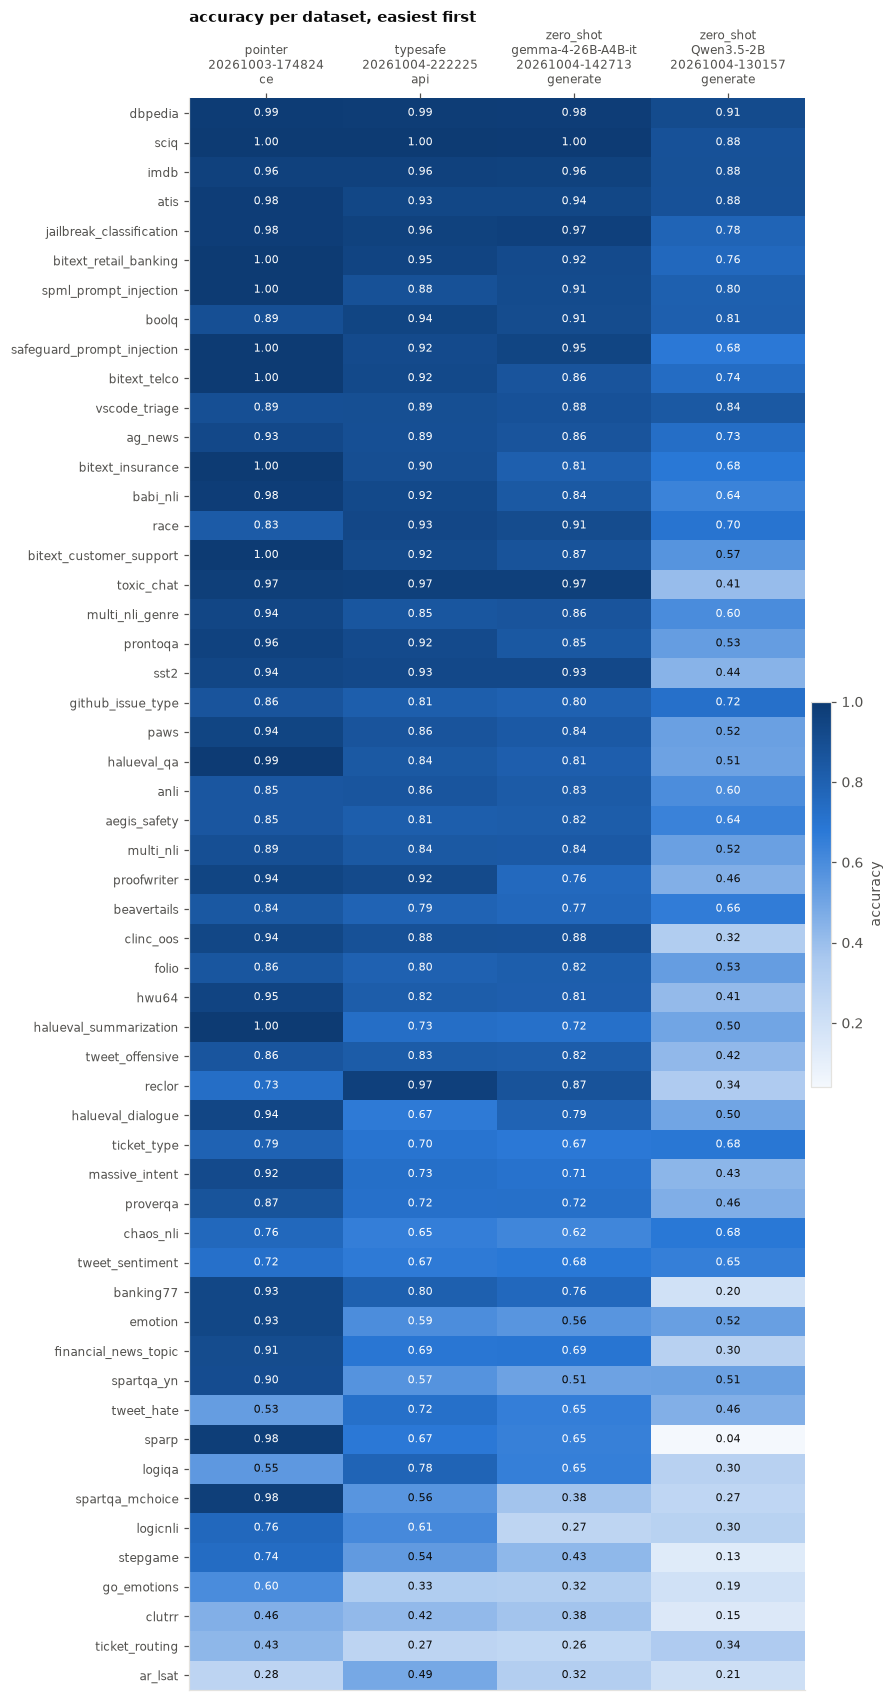

In [6]:
rows = table.loc[table.mean(axis=1).sort_values(ascending=not HIGHER_IS_BETTER[METRIC]).index]
cols = list(leaderboard.index)
fig, ax = plt.subplots(figsize=(1.3 * len(cols) + 3, 0.26 * len(rows) + 1.5))
cmap = SEQUENTIAL if HIGHER_IS_BETTER[METRIC] else SEQUENTIAL.reversed()
image = ax.imshow(rows[cols].to_numpy(), aspect="auto", cmap=cmap)
ax.set_xticks(range(len(cols)), [c.replace(" / ", " ").replace(" ", "\n") for c in cols], fontsize=8)
ax.set_yticks(range(len(rows)), rows.index, fontsize=8)
ax.xaxis.tick_top()
ax.grid(False)
low, high = np.nanmin(rows.to_numpy()), np.nanmax(rows.to_numpy())
for i, (_, row) in enumerate(rows[cols].iterrows()):
    for j, v in enumerate(row):
        if not math.isnan(v):
            dark = (v - low) / ((high - low) or 1) > 0.55
            dark = dark if HIGHER_IS_BETTER[METRIC] else not dark
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white" if dark else INK)
fig.colorbar(image, ax=ax, fraction=0.03, pad=0.01, label=METRIC)
ax.set_title(f"{METRIC} per dataset, easiest first", pad=50)
fig.tight_layout()